# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Creating class MLP only using numpy

In [3]:
class MLP_NP:
    def __init__(self, MLP_architecture, learning_rate, momentum, activation_function='sigmoid'):
       
        """
        MLP_architecture: [input_size (dataset features), hidden_layer1_size, hidden_layer2_size, ..., output_size (possible classes)]
        learning_rate: learning rate for weight updates
        momentum: momentum factor for weight updates
        activation_function: choice of activation function for hidden layers (default is 'sigmoid', can also be 'relu') and 'softmax' for output layer
        """
        self.MLP_architecture = MLP_architecture
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.activation_function = activation_function

        """
        weights: list of weight matrices for each layer (including input to first hidden layer and last hidden layer to output layer)
        biases: list of bias vectors for each layer (including first hidden layer and output layer)
        weight_speed: list of matrices to store the previous weight updates for momentum calculation
        bias_speed: list of vectors to store the previous bias updates for momentum calculation
        """
        self.weights = []
        self.biases = []
        self.weight_speed = []
        self.biases_speed = []
       
        # initialization of the weights and biases
        for i in range(len(MLP_architecture) - 1):
       
            # input and output size for the current layer
            input_size = MLP_architecture[i]
            output_size = MLP_architecture[i + 1]
            
            # initialize weights with small random values and biases with zeros
            weight_matrix = np.random.randn(input_size, output_size) * 0.1
            bias_vector = np.zeros((1, output_size))
           
            # store the initialized weights and biases in the respective lists
            self.weights.append(weight_matrix)
            self.biases.append(bias_vector)

            # Initialize speed matrices for momentum
            self.weight_speed.append(np.zeros_like(weight_matrix))
            self.biases_speed.append(np.zeros_like(bias_vector))
    
    """
    Activation functions: Sigmoid, ReLU, softmax, and their derivatives
    their porpouse is to introduce non-linearity into the model, allowing it to learn complex patterns in the data. The derivatives are used during backpropagation to compute gradients for weight updates.
    """
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    
    def sigmoid_derivative(self, x):
        s = self.sigmoid(x)
        return s * (1 - s)
    
    def relu(self, x):
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        return (x > 0).astype(float)
    
    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)
    
    """
    Forward pass: computes the output of the network for a given input by passing the data through each layer and applying the activation functions.
    """
    def forward_pass(self, X):

        """
        X: input data (shape: [num_samples, input_size])
        layer_inputs: list to store the inputs to each layer (including the original input X) for use in backpropagation
        layer_outputs: list to store the outputs of each layer for use in backpropagation
        """
        self.layer_inputs = []  
        self.layer_outputs = [] 
        
        input_data = X
        for i in range(len(self.MLP_architecture) - 1):

            # Compute the linear transformation (z) for the current layer and store it for backpropagation
            z = np.dot(input_data, self.weights[i]) + self.biases[i]
            self.layer_inputs.append(z)

            # Apply the appropriate activation function based on the layer type and the function specified in the constructor
            if i < len(self.MLP_architecture) - 2:  # Hidden layers
                if self.activation_function == 'sigmoid':
                    output_data = self.sigmoid(z)
                elif self.activation_function == 'relu':
                    output_data = self.relu(z)
                else:
                    raise ValueError("Unsupported activation function for hidden layers.")

            # aplying softmax activation function to the output layer regardless of the specified activation function for hidden layers, as softmax is typically used for multi-class classification problems        
            else:
                output_data = self.softmax(z)

            # Store the output of the current layer
            self.layer_outputs.append(output_data) 
            
            # The output of the current layer becomes the input for the next layer
            input_data = output_data  
        
        # Return the final output of the network
        return input_data  
    
    """
    Backward pass: computes the gradients of the loss with respect to the weights and biases by propagating the error backward through the network using the chain rule of calculus.
    """
    def backward_pass(self, X, y_true):

        # number of samples and predicted output from the forward pass
        m = X.shape[0] 
        y_pred = self.layer_outputs[-1] 

        # Compute the error at the output layer (using cross-entropy + softmax results in a simplified gradient)
        error = y_pred - y_true

        # Backpropagate the error through the layers in reverse order
        for i in reversed(range(len(self.MLP_architecture) - 1)):
            
            # seeing if is the first hidden layer (i=0) to determine the input for gradient calculation
            if i == 0:
                A_prev = X
            else:
                A_prev = self.layer_outputs[i - 1]

            # Calculate the gradients (dW and db) for the current layer
            dW = (1 / m) * np.dot(A_prev.T, error)
            db = (1 / m) * np.sum(error, axis=0, keepdims=True)

            # propagate the error to the previous layer (if not the first layer)
            if i > 0:

                # multiply the current error by the weights of the current layer (transposed) to get the error for the previous layer
                propagation_error = np.dot(error, self.weights[i].T)  
                
                # Apply the derivative of the activation function of the previous layer to the propagated error
                if self.activation_function == 'sigmoid':
                    activation_derivative = self.sigmoid_derivative(self.layer_inputs[i - 1])
                elif self.activation_function == 'relu':
                    activation_derivative = self.relu_derivative(self.layer_inputs[i - 1])
                else:
                    raise ValueError("Unsupported activation function for hidden layers.")
                
                # Update the error variable for the next iteration of the loop to continue backpropagation
                error = propagation_error * activation_derivative
            
            # calculate the momentum updates for weights and biases
            self.weight_speed[i] = self.momentum * self.weight_speed[i] - (self.learning_rate) * dW
            self.biases_speed[i] = self.momentum * self.biases_speed[i] - (self.learning_rate) * db

            # Update the weights and biases using the calculated momentum updates
            self.weights[i] += self.weight_speed[i]
            self.biases[i] += self.biases_speed[i]

# Preparing the training functions for the MLP

## A simple function for a single training run with a specific set of hyperparameters.

In [4]:
def single_train(X_train, y_train, epochs):
    # Get user input for the architecture of the MLP, learning rate, momentum, and activation function
    
    # Geting the number of hidden layers to construct the architecture of the MLP
    hidden_layer_sizes = []
    number_of_hidden_layers = int(input("Enter the number of hidden layers: "))
    for i in range(number_of_hidden_layers):

        # Get the size of each hidden layer from the user and store it in a list
        hidden_layer_size = int(input(f"Enter the size of hidden layer {i + 1}: "))
        hidden_layer_sizes.append(hidden_layer_size)

    # Creating the architecture of the MLP based on the input size, hidden layer sizes, and output size
    architecture = [X_train.shape[1]] + hidden_layer_sizes + [y_train.shape[1]]
    
    # Get user input for learning rate, momentum, and activation function for hidden layers
    learning_rate = float(input("Enter the learning rate: "))

    momentum = float(input("Enter the momentum factor: "))

    activation_function = input("Enter the activation function for hidden layers (sigmoid or relu): ")

    # Create an instance of the MLP_NP class with the specified architecture, learning rate, momentum, and activation function
    MLP_model = MLP_NP(architecture, learning_rate, momentum, activation_function)
    
    # Train the MLP for the specified number of epochs, performing forward and backward passes and printing the loss at each epoch
    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}/{epochs}")
        
        # Perform a forward pass to compute the predicted output
        y_pred = MLP_model.forward_pass(X_train)

        # Perform a backward pass to compute the gradients and update the weights and biases
        MLP_model.backward_pass(X_train, y_train)
 
        # print the loss for the current epoch (using cross-entropy loss)
        loss = np.mean(np.sum(-y_train * np.log(y_pred + 1e-8), axis=1))
        print(f"Epoch Loss: {loss:.4f}")
    
    # After training, return the final loss for this configuration
    y_pred = MLP_model.forward_pass(X_train)
    loss = np.mean(np.sum(-y_train * np.log(y_pred + 1e-8), axis=1))
    print(f"Final Loss for this configuration: {loss:.4f}")
    return loss, MLP_model

## A function that performs a random search for hyperparameters and selects the best model.

In [5]:
def train_random_aux(X_train, y_train, epochs, architecture, learning_rate, momentum, activation_function):
    full_architecture = [X_train.shape[1]] + architecture + [y_train.shape[1]]
    # Create an instance of the MLP_NP class with the specified architecture, learning rate, momentum, and activation function
    MLP_model = MLP_NP(full_architecture, learning_rate, momentum, activation_function)
    
    # Train the MLP for the specified number of epochs, performing forward and backward passes and printing the loss at each epoch
    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}/{epochs}")
        
        # Perform a forward pass to compute the predicted output
        y_pred = MLP_model.forward_pass(X_train)

        # Perform a backward pass to compute the gradients and update the weights and biases
        MLP_model.backward_pass(X_train, y_train)
 
        # print the loss for the current epoch (using cross-entropy loss)
        loss = np.mean(np.sum(-y_train * np.log(y_pred + 1e-8), axis=1))
        print(f"Epoch Loss: {loss:.4f}")
    
    # After training, return the final loss for this configuration
    y_pred = MLP_model.forward_pass(X_train)
    loss = np.mean(np.sum(-y_train * np.log(y_pred + 1e-8), axis=1))
    print(f"Final Loss for this configuration: {loss:.4f}")
    return loss, MLP_model


def creating_random_architecture(num_random):    

    # creating the dictionary of lists for each hyperparameter to store the random values
    random_parameters = {   
        'hidden_layer': [],
        'learning_rate': [],
        'momentum': [],
        'activation_function': []
    }

    # creating predefined options for each hyperparameter to ensure a more meaningful search space for the random configurations

    # hidden layer architectures with varying number of layers and sizes to provide a diverse set of configurations for the MLP
    arquiteturas_opcoes = [
        [16],              
        [32, 32],          
        [16, 32],          
        [10, 20],          
        [16, 32, 64],      
        [64, 128, 64],
        [128, 64, 32],     
        [32, 64, 128],     
        [16, 16, 16],
        [8, 16, 32],
        [16, 32, 16]  
    ]
    
    # learning rates that span several orders of magnitude to allow for a wide exploration of the learning rate hyperparameter, which can significantly impact the training process and convergence of the MLP
    learning_rate_opcoes = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]
    
    # momentum values that are commonly used in training neural networks to help accelerate convergence and avoid local minima by adding a fraction of the previous weight update to the current update
    momentum_opcoes = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
    
    # activation functions that are widely used in neural networks to introduce non-linearity and allow the model to learn complex patterns in the data, with sigmoid being a traditional choice and ReLU being a popular choice for hidden layers due to its computational efficiency and ability to mitigate the vanishing gradient problem
    activation_opcoes = ['sigmoid', 'relu']
    
    # Generate random configurations for the specified number of times and store them in the respective lists
    for seed in range(1, num_random+1):
        random.seed(seed)

        hidden_layer_sizes = random.choice(arquiteturas_opcoes)
        random_parameters['hidden_layer'].append(hidden_layer_sizes)

        learning_rate = random.choice(learning_rate_opcoes)
        random_parameters['learning_rate'].append(learning_rate)

        momentum = random.choice(momentum_opcoes)
        random_parameters['momentum'].append(momentum)

        activation_function = random.choice(activation_opcoes)
        random_parameters['activation_function'].append(activation_function)
    
    return random_parameters



def random_train(X_train, y_train, epochs):
    # Get the number of random configurations to try
    num_random_configs = int(input("Enter the number of random configurations to try: "))
    
    # Generate random configurations for the specified number of times
    random_parameters = creating_random_architecture(num_random_configs)

    # Train the MLP with each random configuration and store the results
    results = []
    for i in range(num_random_configs):
        print(f"Training with random configuration {i + 1}/{num_random_configs}")
        
        # Extract the random hyperparameters for the current configuration
        architecture = random_parameters['hidden_layer'][i]
        learning_rate = random_parameters['learning_rate'][i]
        momentum = random_parameters['momentum'][i]
        activation_function = random_parameters['activation_function'][i]

        # Train the MLP with the current random configuration and store the predicted output and loss
        loss, current_MLP_model = train_random_aux(X_train, y_train, epochs, architecture, learning_rate, momentum, activation_function)
        
        # Store the results for the current configuration in a dictionary and append it to the results list
        config_result = {
            'architecture': architecture,
            'learning_rate': learning_rate,
            'momentum': momentum,
            'activation_function': activation_function,
            'loss': loss,
            'model': current_MLP_model
        }
        results.append(config_result)

    # fiding the best configuration based on the lowest loss and returning the corresponding model
    best_config = min(results, key=lambda x: x['loss'])

    print(f"Best configuration found:")
    print(f" Architecture: {best_config['architecture']}") 
    print(f" Learning Rate: {best_config['learning_rate']}") 
    print(f" Momentum: {best_config['momentum']}") 
    print(f" Activation Function: {best_config['activation_function']}") 
    print(f" Loss: {best_config['loss']:.4f}")
    
    return best_config['model'], best_config, results

# Training the MLP numpy version

## training with a single set of hyperparameters

Epoch 1/100
Epoch Loss: 1.1246
Epoch 2/100
Epoch Loss: 1.1200
Epoch 3/100
Epoch Loss: 1.1157
Epoch 4/100
Epoch Loss: 1.1161
Epoch 5/100
Epoch Loss: 1.1205
Epoch 6/100
Epoch Loss: 1.1240
Epoch 7/100
Epoch Loss: 1.1230
Epoch 8/100
Epoch Loss: 1.1183
Epoch 9/100
Epoch Loss: 1.1145
Epoch 10/100
Epoch Loss: 1.1152
Epoch 11/100
Epoch Loss: 1.1194
Epoch 12/100
Epoch Loss: 1.1222
Epoch 13/100
Epoch Loss: 1.1201
Epoch 14/100
Epoch Loss: 1.1152
Epoch 15/100
Epoch Loss: 1.1120
Epoch 16/100
Epoch Loss: 1.1133
Epoch 17/100
Epoch Loss: 1.1170
Epoch 18/100
Epoch Loss: 1.1185
Epoch 19/100
Epoch Loss: 1.1156
Epoch 20/100
Epoch Loss: 1.1105
Epoch 21/100
Epoch Loss: 1.1075
Epoch 22/100
Epoch Loss: 1.1086
Epoch 23/100
Epoch Loss: 1.1114
Epoch 24/100
Epoch Loss: 1.1115
Epoch 25/100
Epoch Loss: 1.1072
Epoch 26/100
Epoch Loss: 1.1012
Epoch 27/100
Epoch Loss: 1.0978
Epoch 28/100
Epoch Loss: 1.0978
Epoch 29/100
Epoch Loss: 1.0984
Epoch 30/100
Epoch Loss: 1.0955
Epoch 31/100
Epoch Loss: 1.0884
Epoch 32/100
Epoc

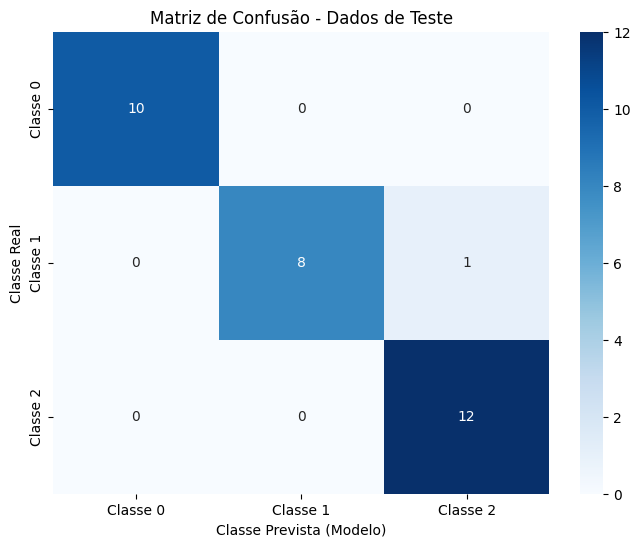

In [18]:
# loading the scaled data and encoded labels for training the MLP model
X_train_scaled = np.loadtxt('..\\data\\X_train_scaled.csv', delimiter=',')
y_train_encoded = np.loadtxt('..\\data\\y_train_encoded.csv', delimiter=',')

# loading the test data for later evaluation of the MLP model
X_test_scaled = np.loadtxt('..\\data\\X_test_scaled.csv', delimiter=',')   
y_test_encoded = np.loadtxt('..\\data\\y_test_encoded.csv', delimiter=',')

# undoing the one-hot encoding to calculate the test loss and accuracy after training the MLP models
y_test_true_labels_single = np.argmax(y_test_encoded, axis=1)

# Example of training the MLP with user-defined architecture and hyperparameters
final_loss_single, trained_model_single = single_train(X_train_scaled, y_train_encoded, epochs=100)

# seeing the test loss for the model trained with user-defined hyperparameters
y_test_pred_single = trained_model_single.forward_pass(X_test_scaled)

# undooing the one-hot encoding from the predicted output to get the predicted class labels for the test set
y_test_pred_labels_single = np.argmax(y_test_pred_single, axis=1)

# calculating the metrics for the model trained with user-defined hyperparameters

# calculating the test loss using cross-entropy loss formula
test_loss_single = np.mean(np.sum(-y_test_encoded * np.log(y_test_pred_single + 1e-8), axis=1))
print(f"Test Loss for the model trained with user-defined hyperparameters: {test_loss_single:.4f}")

# calculating the test accuracy by comparing the true labels with the predicted labels for the test set
test_accuracy_single = accuracy_score(y_test_true_labels_single, y_test_pred_labels_single)
print(f"Test Accuracy for the model trained with user-defined hyperparameters: {test_accuracy_single:.4f}")

# calculating the precision, recall, and F1-score for each class using the true labels and predicted labels for the test set
classification_rep_single = classification_report(y_test_true_labels_single, y_test_pred_labels_single)
print(f"Classification Report for the model trained with user-defined hyperparameters:\n{classification_rep_single}")

# plotting the confusion matrix for the model trained with user-defined hyperparameters to visualize the performance of the model in terms of true positives, true negatives, false positives, and false negatives for each class
cm = confusion_matrix(y_test_true_labels_single, y_test_pred_labels_single)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Classe 0', 'Classe 1', 'Classe 2'], 
            yticklabels=['Classe 0', 'Classe 1', 'Classe 2'])
plt.title('Matriz de Confusão - Dados de Teste')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista (Modelo)')
plt.show()

## training with the random method

Training with random configuration 1/500
Epoch 1/100
Epoch Loss: 1.1216
Epoch 2/100
Epoch Loss: 1.1212
Epoch 3/100
Epoch Loss: 1.1204
Epoch 4/100
Epoch Loss: 1.1194
Epoch 5/100
Epoch Loss: 1.1183
Epoch 6/100
Epoch Loss: 1.1172
Epoch 7/100
Epoch Loss: 1.1162
Epoch 8/100
Epoch Loss: 1.1155
Epoch 9/100
Epoch Loss: 1.1151
Epoch 10/100
Epoch Loss: 1.1151
Epoch 11/100
Epoch Loss: 1.1154
Epoch 12/100
Epoch Loss: 1.1160
Epoch 13/100
Epoch Loss: 1.1167
Epoch 14/100
Epoch Loss: 1.1176
Epoch 15/100
Epoch Loss: 1.1185
Epoch 16/100
Epoch Loss: 1.1192
Epoch 17/100
Epoch Loss: 1.1197
Epoch 18/100
Epoch Loss: 1.1199
Epoch 19/100
Epoch Loss: 1.1199
Epoch 20/100
Epoch Loss: 1.1195
Epoch 21/100
Epoch Loss: 1.1188
Epoch 22/100
Epoch Loss: 1.1180
Epoch 23/100
Epoch Loss: 1.1170
Epoch 24/100
Epoch Loss: 1.1160
Epoch 25/100
Epoch Loss: 1.1151
Epoch 26/100
Epoch Loss: 1.1144
Epoch 27/100
Epoch Loss: 1.1140
Epoch 28/100
Epoch Loss: 1.1138
Epoch 29/100
Epoch Loss: 1.1139
Epoch 30/100
Epoch Loss: 1.1142
Epoch 31

C:\Users\Guilherme\AppData\Local\Temp\ipykernel_13008\2484621655.py:83: RuntimeWarning: overflow encountered in dot
  z = np.dot(input_data, self.weights[i]) + self.biases[i]


Epoch Loss: 1.0293
Epoch 62/100
Epoch Loss: 1.0274
Epoch 63/100
Epoch Loss: 1.0254
Epoch 64/100
Epoch Loss: 1.0235
Epoch 65/100
Epoch Loss: 1.0215
Epoch 66/100
Epoch Loss: 1.0194
Epoch 67/100
Epoch Loss: 1.0174
Epoch 68/100
Epoch Loss: 1.0153
Epoch 69/100
Epoch Loss: 1.0131
Epoch 70/100
Epoch Loss: 1.0110
Epoch 71/100
Epoch Loss: 1.0088
Epoch 72/100
Epoch Loss: 1.0066
Epoch 73/100
Epoch Loss: 1.0043
Epoch 74/100
Epoch Loss: 1.0021
Epoch 75/100
Epoch Loss: 0.9997
Epoch 76/100
Epoch Loss: 0.9974
Epoch 77/100
Epoch Loss: 0.9950
Epoch 78/100
Epoch Loss: 0.9926
Epoch 79/100
Epoch Loss: 0.9901
Epoch 80/100
Epoch Loss: 0.9876
Epoch 81/100
Epoch Loss: 0.9850
Epoch 82/100
Epoch Loss: 0.9825
Epoch 83/100
Epoch Loss: 0.9798
Epoch 84/100
Epoch Loss: 0.9772
Epoch 85/100
Epoch Loss: 0.9745
Epoch 86/100
Epoch Loss: 0.9717
Epoch 87/100
Epoch Loss: 0.9690
Epoch 88/100
Epoch Loss: 0.9661
Epoch 89/100
Epoch Loss: 0.9633
Epoch 90/100
Epoch Loss: 0.9604
Epoch 91/100
Epoch Loss: 0.9574
Epoch 92/100
Epoch Lo

C:\Users\Guilherme\AppData\Local\Temp\ipykernel_13008\2484621655.py:83: RuntimeWarning: invalid value encountered in dot
  z = np.dot(input_data, self.weights[i]) + self.biases[i]


Epoch Loss: 0.9224
Epoch 100/100
Epoch Loss: 0.9161
Final Loss for this configuration: 0.9096
Training with random configuration 55/500
Epoch 1/100
Epoch Loss: 1.1324
Epoch 2/100
Epoch Loss: 1.1324
Epoch 3/100
Epoch Loss: 1.1324
Epoch 4/100
Epoch Loss: 1.1323
Epoch 5/100
Epoch Loss: 1.1323
Epoch 6/100
Epoch Loss: 1.1322
Epoch 7/100
Epoch Loss: 1.1321
Epoch 8/100
Epoch Loss: 1.1321
Epoch 9/100
Epoch Loss: 1.1320
Epoch 10/100
Epoch Loss: 1.1319
Epoch 11/100
Epoch Loss: 1.1318
Epoch 12/100
Epoch Loss: 1.1318
Epoch 13/100
Epoch Loss: 1.1317
Epoch 14/100
Epoch Loss: 1.1316
Epoch 15/100
Epoch Loss: 1.1316
Epoch 16/100
Epoch Loss: 1.1315
Epoch 17/100
Epoch Loss: 1.1314
Epoch 18/100
Epoch Loss: 1.1314
Epoch 19/100
Epoch Loss: 1.1313
Epoch 20/100
Epoch Loss: 1.1312
Epoch 21/100
Epoch Loss: 1.1311
Epoch 22/100
Epoch Loss: 1.1311
Epoch 23/100
Epoch Loss: 1.1310
Epoch 24/100
Epoch Loss: 1.1309
Epoch 25/100
Epoch Loss: 1.1309
Epoch 26/100
Epoch Loss: 1.1308
Epoch 27/100
Epoch Loss: 1.1307
Epoch 28/

C:\Users\Guilherme\AppData\Local\Temp\ipykernel_13008\2484621655.py:63: RuntimeWarning: invalid value encountered in subtract
  exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
C:\Users\Guilherme\AppData\Local\Temp\ipykernel_13008\2484621655.py:137: RuntimeWarning: overflow encountered in dot
  propagation_error = np.dot(error, self.weights[i].T)
C:\Users\Guilherme\AppData\Local\Temp\ipykernel_13008\2484621655.py:148: RuntimeWarning: invalid value encountered in multiply
  error = propagation_error * activation_derivative


Epoch Loss: 1.1030
Epoch 95/100
Epoch Loss: 1.1028
Epoch 96/100
Epoch Loss: 1.1026
Epoch 97/100
Epoch Loss: 1.1024
Epoch 98/100
Epoch Loss: 1.1021
Epoch 99/100
Epoch Loss: 1.1019
Epoch 100/100
Epoch Loss: 1.1017
Final Loss for this configuration: 1.1015
Training with random configuration 88/500
Epoch 1/100
Epoch Loss: 1.1905
Epoch 2/100
Epoch Loss: 1.1903
Epoch 3/100
Epoch Loss: 1.1900
Epoch 4/100
Epoch Loss: 1.1895
Epoch 5/100
Epoch Loss: 1.1890
Epoch 6/100
Epoch Loss: 1.1884
Epoch 7/100
Epoch Loss: 1.1878
Epoch 8/100
Epoch Loss: 1.1872
Epoch 9/100
Epoch Loss: 1.1866
Epoch 10/100
Epoch Loss: 1.1860
Epoch 11/100
Epoch Loss: 1.1853
Epoch 12/100
Epoch Loss: 1.1847
Epoch 13/100
Epoch Loss: 1.1841
Epoch 14/100
Epoch Loss: 1.1834
Epoch 15/100
Epoch Loss: 1.1828
Epoch 16/100
Epoch Loss: 1.1822
Epoch 17/100
Epoch Loss: 1.1816
Epoch 18/100
Epoch Loss: 1.1810
Epoch 19/100
Epoch Loss: 1.1803
Epoch 20/100
Epoch Loss: 1.1797
Epoch 21/100
Epoch Loss: 1.1791
Epoch 22/100
Epoch Loss: 1.1786
Epoch 23/

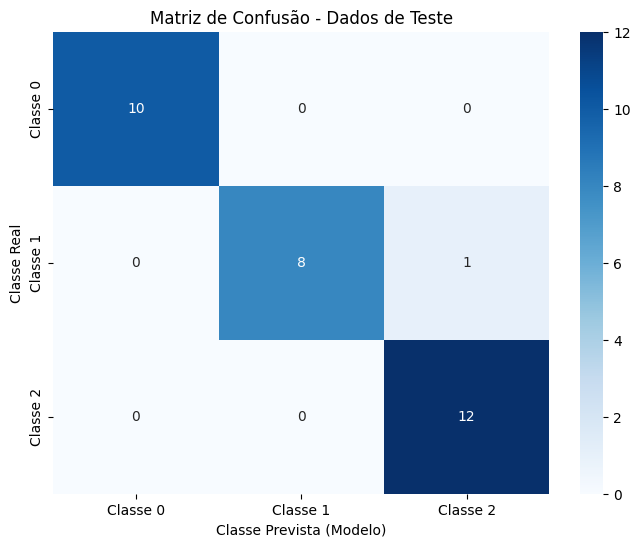

In [11]:
# loading the scaled data and encoded labels for training the MLP model
X_train_scaled = np.loadtxt('..\\data\\X_train_scaled.csv', delimiter=',')
y_train_encoded = np.loadtxt('..\\data\\y_train_encoded.csv', delimiter=',')

# loading the test data for later evaluation of the best MLP model found
X_test_scaled = np.loadtxt('..\\data\\X_test_scaled.csv', delimiter=',')   
y_test_encoded = np.loadtxt('..\\data\\y_test_encoded.csv', delimiter=',')

# undoing the one-hot encoding to calculate the test loss and accuracy after training the MLP models
y_test_true_labels_random = np.argmax(y_test_encoded, axis=1)

# Executing the random search method to train multiple configurations and find the best MLP architecture and hyperparameters
trained_model_random, parameters, all_results = random_train(X_train_scaled, y_train_encoded, epochs=100)

# getting the predictions to calculate the test loss for the best model found by the random search method
y_test_pred_random = trained_model_random.forward_pass(X_test_scaled)

# undoing the one-hot encoding from the predicted output to get the predicted class labels for the test set
y_test_pred_labels_random = np.argmax(y_test_pred_random, axis=1)

# calculating the evaluation metrics for the best model found by the random search method

# calculating the test loss using cross-entropy loss formula
test_loss_random = np.mean(np.sum(-y_test_encoded * np.log(y_test_pred_random + 1e-8), axis=1))
print(f"Test Loss for the best model found by random search: {test_loss_random:.4f}")

# calculating the test accuracy by comparing the true labels with the predicted labels for the test set
test_accuracy_random = accuracy_score(y_test_true_labels_random, y_test_pred_labels_random)
print(f"Test Accuracy for the best model found by random search: {test_accuracy_random:.4f}")

# calculating the precision, recall, and F1-score for each class using the true labels and predicted labels for the test set
classification_rep_random = classification_report(y_test_true_labels_random, y_test_pred_labels_random)
print(f"Classification Report for the best model found by random search:\n{classification_rep_random}")

# plotting the confusion matrix for the best model found by the random search method to visualize the performance of the model in terms of true positives, true negatives, false positives, and false negatives for each class
cm = confusion_matrix(y_test_true_labels_random, y_test_pred_labels_random)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Classe 0', 'Classe 1', 'Classe 2'], 
            yticklabels=['Classe 0', 'Classe 1', 'Classe 2'])
plt.title('Matriz de Confusão - Dados de Teste')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista (Modelo)')
plt.show()